# SIOC 251: Homework 2: Radiative Forcing 

## Part I: Weighting Function

With a well-mixed gas with extinction coefficient

$$\beta_e(z) = C \exp(-z/H)$$

where $C = f \times 1.25 \times 10^{-4}\ \text{m}^{-1}$ and $H$ is the atmospheric scale height (we use $H = 8000$ m).

### 1. Expressions for $\tau(z)$ and $\tau^*$

$$\tau(z) = \int_z^\infty \beta_e(z')\,dz' = \int_z^\infty C\,e^{-z'/H}\,dz' = CH\,e^{-z/H}$$

Therefore

$$\boxed{\tau(z) = CH\,e^{-z/H}}$$

At the surface (where $z=0$):

$$\boxed{\tau^* = \tau(0) = CH}$$

### 2. Expression for $t_F(z, \infty)$

The flux transmittance uses the approximation

$$t_F(z,\infty) \approx \exp\!\left(-\bar{r}\,\tau(z)\right),\qquad \bar{r}=1/\bar{\mu}$$

Substituting $\tau(z)$ leads to

$$\boxed{t_F(z,\infty) = \exp\!\left[-\bar{r}\,CH\,e^{-z/H}\right]}$$

### 3. Expression for $W^{\uparrow}_F(z)$

Since we knoe $W^{\uparrow}_F(z) = \dfrac{\partial t_F(z,\infty;\mu)}{\partial z} $

Differentiating with respect to $z$ gives 

$$W^{\uparrow}_F(z) = \bar{r}\,C\,e^{-z/H}\cdot \exp\!\left[-\bar{r}\,CH\,e^{-z/H}\right]$$

And finally, replacing terms, we get the full equation as

$$\boxed{W^{\uparrow}_F(z) = \bar{r}\,\beta_e(z)\,t_F(z,\infty)}$$

### 4. Plotting $W^{\uparrow}_F(z)$ for different $f$ values

The following code plots the function $W^{\uparrow}_F(z)$ shown above overlaying $f = 0.001, 0.01, 0.1, 1, 10, 100$ using $\bar{r} = 5/3 = 1.66$ and $H = 8.5$ km.

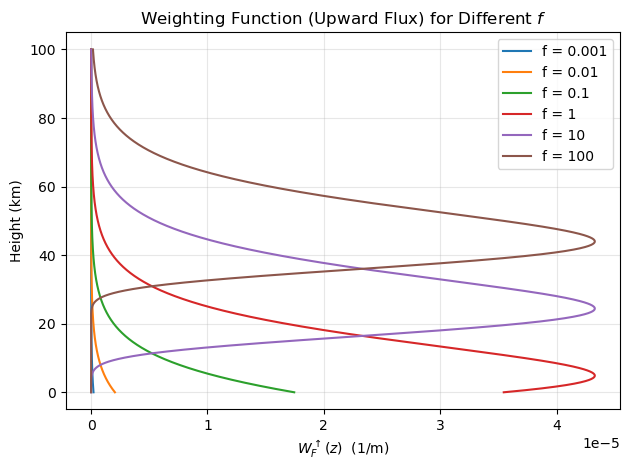

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# constants
H = 8500 # scale height 
r_bar = 5/3 # diffusivity
C_init = 1.25e-4                

# heights
z = np.linspace(0, 100000, 5000)

# f values
f_values = [0.001, 0.01, 0.1, 1, 10, 100]

# weighting function
def W_F(z, f, H=H, r_bar=r_bar, C_init=C_init):
    C = f*C_init
    beta_e = C*np.exp(-z/H)
    tau = C*H*np.exp(-z/H)
    t_F = np.exp(-r_bar*tau)
    return r_bar*beta_e*t_F

# plot
fig, ax = plt.subplots()
for f in f_values:
    W = W_F(z, f)
    ax.plot(W, z/1000, label=f"f = {f}")
ax.set_xlabel(r'$W^{\uparrow}_F(z)$  (1/m)')
ax.set_ylabel('Height (km)')
ax.set_title('Weighting Function (Upward Flux) for Different $f$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim()
plt.show()

As $f$ increases, the peak of $W^{\uparrow}_F(z)$ shifts upward in the atmosphere. For small $f$ (.1, .01, .001) the peak theoretically sits below the surface, so the curves drop at $z$=0. For larger $f$, a clear peak appears at specific heights, and that rises higher with each increase in $f$.

### 5. Effect of changes in $W^{\uparrow}_F(z)$ on TOA outgoing LW radiation

As $f$ increases, the gas concentration goes up and the atmosphere becomes more opaque. The noticeable peaks of $W^{\uparrow}_F(z)$ for different $f$, shown above in the plot, shifts upward (the level of emission moves higher in the atmosphere with increasing gas concentration).

Because temperature decreases with height in the troposphere, the upward LW radiation at the TOA comes from colder layers of air. By the Planck function, colder emission would mean *less outgoing LW radiation at TOA* as $f$ grows. 

For very small $f$, the atmosphere is nearly transparent and most of the outgoing LW comes from a warmer surface, so the TOA outgoing LW is much larger.

## Part II: TOA Outgoing LW Radiation
### 1. Expression for monochromatic upwelling flux at TOA

The upwelling flux measured at the top of the atmosphere comes from the emission from the surface that makes it through the atmosphere as well as emission from the atmosphere

$$F^{\uparrow}_\lambda(\infty) = \pi B_\lambda(T_s)\,t_F(0,\infty) \;+\; \int_0^\infty \pi B_\lambda[T(z)]\,W^{\uparrow}_F(z)\,dz$$

The first term is surface emission through the whole atmosphere. The second term sums up the emission from each atmosphere layer.

### 2. Monochromatic net flux at TOA

The net flux is the difference between energy leaving and entering the top of the atmosphere. Since there is no incoming source from space, the down flux at TOA is zero and the net flux is just the up flux

$$F_{n,\lambda}(\infty) = F^{\uparrow}_\lambda(\infty) - F^{\downarrow}_\lambda(\infty) = F^{\uparrow}_\lambda(\infty)$$

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# constants
h = 6.626e-34 # planck's constant 
c = 3e8 #speed of light            
kB = 1.381e-23 # boltzmann constant 
H = 8500 # scale height (m)
r_bar = 5/3 # diffusivity factor
C_init = 1.25e-4 # base extinction coefficient
lam = 15e-6 # wavelength (m)

# planck function
def B_lam(T, lam=lam):
    return (2*h*c**2/lam**5) / (np.exp(h*c/(lam*kB*T)) - 1.0)

# flux transmittance from z to TOA
def t_F(z, f):
    C = f*C_init
    tau = C*H*np.exp(-z/H)
    return np.exp(-r_bar*tau)

# upward flux weighting function (as before)
def W_F(z, f):
    C = f*C_init
    beta_e = C*np.exp(-z/H)
    return r_bar*beta_e*t_F(z, f)

# compute F at TOA 
def F_TOA(f, T_func, z_max=200000, n=100000):
    z = np.linspace(0, z_max, n)
    Ts = T_func(0.0)
    F_sfc = np.pi*B_lam(Ts)*t_F(0.0, f)
    F_atm = np.trapezoid(np.pi*B_lam(T_func(z))*W_F(z, f), z)
    return F_sfc + F_atm

# f range
f_array = np.logspace(-3, 3, 200)

### Temperature Profile (1): 

$$T(z) = \begin{cases} T_s - \Gamma z, & z \le 20\text{ km} \\ 200\text{ K}, & z > 20\text{ km} \end{cases}$$

with $T_s = 300$ K and $\Gamma = 5$ K km$^{-1}$.

### 3/4 (1). The following code computes and plots $F_{n,\lambda}(\infty)$ and $\Delta F(\infty)$ for the temperature profile above:

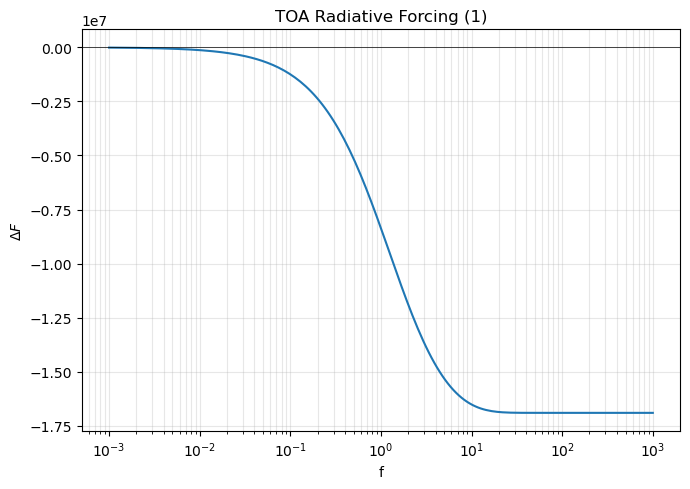

In [81]:
def T_profile1(z):
    return np.where(z <= 20000, 300.0 - 5e-3*z, 200.0)

F_n_p1 = np.array([F_TOA(f, T_profile1) for f in f_array])
F_n0   = F_TOA(0.0, T_profile1) # f=0 reference parameter
dF_p1  = F_n_p1 - F_n0

fig, ax = plt.subplots(figsize=(7,5))
ax.semilogx(f_array, dF_p1)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('f')
ax.set_ylabel(r'$\Delta F$')
ax.set_title('TOA Radiative Forcing (1)')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 5 (1). Shape of $\Delta F$

For very small $f$, the atmosphere is transparent and emission still effectively comes from the warm surface, so $\Delta F \approx 0$. As $f$ grows, the peak of $W^{\uparrow}_F(z)$ moves upward to colder air, so the atmosphere emits less than the surface did at $\lambda$ as $\Delta F$ becomes increasingly (exponentially) negative. Once $f$ is large enough (at around 10 on the plot above) that the peak rises above 20 km (where $T = 200$ K becomes constant), further increases in $f$ no longer change the temperature, and $\Delta F$ stagnates.

### 6. Temperature Profile (2):

$$T(z) = \begin{cases} T_s - \Gamma z, & z \le 20\text{ km} \\ 200 + \Gamma_sz), & 20 < z \le 50\text{ km} \\ 260\text{ K}, & z > 50\text{ km} \end{cases}$$

Using $\Gamma_s = 2$ K km$^{-1}$ 

### 3/4 (2). The following code computes and plots $F_{n,\lambda}(\infty)$ and $\Delta F(\infty)$ for the temperature profile above:

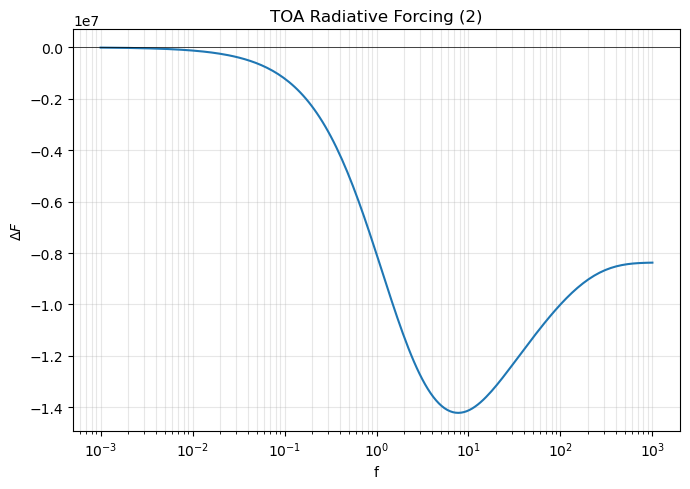

In [82]:
def T_profile2(z):
    z_km = z/1000.0
    T = np.where(z_km <= 20, 300 - 5*z_km,
        np.where(z_km <= 50, 200 + 2*(z_km - 20),260))
    return T

F_n_p2 = np.array([F_TOA(f, T_profile2) for f in f_array])
F_n0_2 = F_TOA(0.0, T_profile2)
dF_p2  = F_n_p2 - F_n0_2

fig, ax = plt.subplots(figsize=(7,5))
ax.semilogx(f_array, dF_p2)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('f')
ax.set_ylabel(r'$\Delta F$')
ax.set_title('TOA Radiative Forcing (2)')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 5 (2). Shape of $\Delta F$

The behavior matches Profile 1 for small and moderate $f$ until around $f = 7$, where we see a peak or trough before the function starts increasing until encountering an asymptote at around $f = 1000$. As the W-peak rises through the troposphere into colder air, $\Delta F$ becomes more negative. But, once $f$ is large enough to push the peak (past $z > 20$ km), the air gets warmer with height again. Emission from this layer is closer to the surface temperature, so $\Delta F$ becomes less negative and the curve heads back towards zero before leveling off at high $f$ and constant $T$.

### 7. Temperature Profile (3):

$$T(z) = 300\text{ K}$$

### 3/4 (3). The following code computes and plots $F_{n,\lambda}(\infty)$ and $\Delta F(\infty)$ for the temperature profile above:

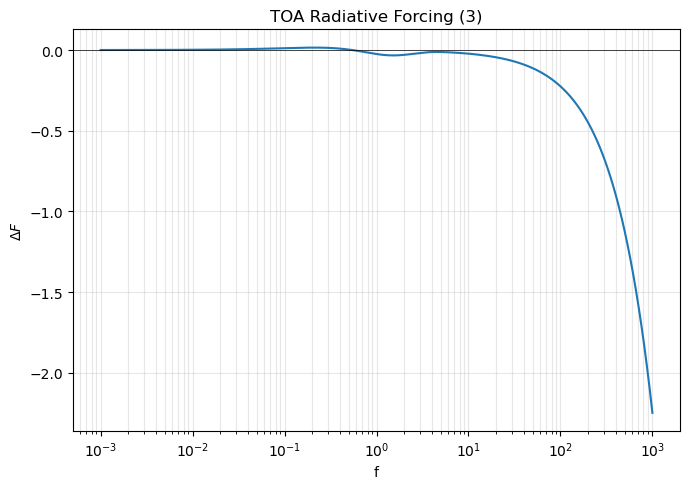

In [83]:
def T_profile3(z):
    return np.full_like(np.asarray(z, dtype=float), 300.0)

F_n_p3 = np.array([F_TOA(f, T_profile3) for f in f_array])
F_n0_3 = F_TOA(0.0, T_profile3)
dF_p3  = F_n_p3 - F_n0_3

fig, ax = plt.subplots(figsize=(7,5))
ax.semilogx(f_array, dF_p3)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('f')
ax.set_ylabel(r'$\Delta F$')
ax.set_title('TOA Radiative Forcing (3)')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 5 (3). Shape of $\Delta F$ 

For an isothermal atmosphere, $\Delta F = 0$ for all $f$. With no vertical temperature gradient, every layer of gas emits at the same temperature as the surface, so atmospheric emission and the net TOA flux never changes (The drop near $f \approx 10$ in the plot seems like an artifact. The true curve should be flat or constant at zero as no temperature gradient analytically relates to no forcing. Previous temp profiles have proven this by $\Delta F$ becoming constant at large $f$ as temperatures become constant in the upper atmosphere).

## AI Contribution (Claude and Visual Studio Code's in-house AI tools)

Use: 

(1) checking derivations of $\tau(z)$, $\tau^*$, $t_F(z,\infty)$, and $W^{\uparrow}_F(z)$

(2) generating Python plotting code for the weighting function across different values of $f$ and refining it with height $z$ to highlight $f$ curves that weren't visible 

(3) setting up numerical integration of the TOA upwelling flux and theoretical explanations for the three temperature profiles

(4) diagnosing an artifact in the temp profile (3) case where $\Delta F$ should be zero that AI wasn't able to correct

(5) all physical interpretations, final answers, and write-ups were reviewed and confirmed after finishing for errors and conflicts